In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
orders = pd.read_csv("../data/raw/olist_orders_dataset.csv")

In [6]:
orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [7]:
%whos

Variable   Type         Data/Info
---------------------------------
np         module       <module 'numpy' from 'D:\<...>ges\\numpy\\__init__.py'>
orders     DataFrame    Shape: (99441, 8)
pd         module       <module 'pandas' from 'D:<...>es\\pandas\\__init__.py'>
plt        module       <module 'matplotlib.pyplo<...>\\matplotlib\\pyplot.py'>
sns        module       <module 'seaborn' from 'D<...>s\\seaborn\\__init__.py'>


In [8]:
orders.shape

(99441, 8)

In [9]:
orders.columns

Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date'],
      dtype='object')

In [10]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


In [11]:
orders.duplicated().sum()

np.int64(0)

In [12]:
orders["order_purchase_timestamp"] = pd.to_datetime(
    orders["order_purchase_timestamp"]
)

In [13]:
orders["order_purchase_timestamp"].dtype

dtype('<M8[ns]')

In [14]:
date_cols = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]

for col in date_cols:
    orders[col] = pd.to_datetime(orders[col])

In [15]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       99441 non-null  object        
 1   customer_id                    99441 non-null  object        
 2   order_status                   99441 non-null  object        
 3   order_purchase_timestamp       99441 non-null  datetime64[ns]
 4   order_approved_at              99281 non-null  datetime64[ns]
 5   order_delivered_carrier_date   97658 non-null  datetime64[ns]
 6   order_delivered_customer_date  96476 non-null  datetime64[ns]
 7   order_estimated_delivery_date  99441 non-null  datetime64[ns]
dtypes: datetime64[ns](5), object(3)
memory usage: 6.1+ MB


In [16]:
orders.isnull().sum()

order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

In [17]:
orders["order_status"].value_counts()

order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

In [18]:
orders["purchase_year"] = orders["order_purchase_timestamp"].dt.year
orders["purchase_month"] = orders["order_purchase_timestamp"].dt.month

In [19]:
orders[["order_purchase_timestamp", "purchase_year", "purchase_month"]].head()

,order_purchase_timestamp,purchase_year,purchase_month
0,2017-10-02 10:56:33,2017,10
1,2018-07-24 20:41:37,2018,7
2,2018-08-08 08:38:49,2018,8
3,2017-11-18 19:28:06,2017,11
4,2018-02-13 21:18:39,2018,2


In [20]:
orders.groupby("order_status")[
    [
        "order_approved_at",
        "order_delivered_carrier_date",
        "order_delivered_customer_date"
    ]
].count()

,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date
order_status,,,
approved,2,0,0
canceled,484,75,6
created,0,0,0
delivered,96464,96476,96470
invoiced,314,0,0
processing,301,0,0
shipped,1107,1107,0
unavailable,609,0,0


In [21]:
orders["purchase_year"].value_counts().sort_index()

purchase_year
2016      329
2017    45101
2018    54011
Name: count, dtype: int64

In [22]:
orders["purchase_month"].value_counts().sort_index()

purchase_month
1      8069
2      8508
3      9893
4      9343
5     10573
6      9412
7     10318
8     10843
9      4305
10     4959
11     7544
12     5674
Name: count, dtype: int64

In [23]:
orders["year_month"] = orders["order_purchase_timestamp"].dt.to_period("M")

In [24]:
orders["year_month"].value_counts().sort_index()

year_month
2016-09       4
2016-10     324
2016-12       1
2017-01     800
2017-02    1780
2017-03    2682
2017-04    2404
2017-05    3700
2017-06    3245
2017-07    4026
2017-08    4331
2017-09    4285
2017-10    4631
2017-11    7544
2017-12    5673
2018-01    7269
2018-02    6728
2018-03    7211
2018-04    6939
2018-05    6873
2018-06    6167
2018-07    6292
2018-08    6512
2018-09      16
2018-10       4
Freq: M, Name: count, dtype: int64

In [25]:
orders["order_purchase_timestamp"].min()

Timestamp('2016-09-04 21:15:19')

In [26]:
orders["order_purchase_timestamp"].max()

Timestamp('2018-10-17 17:30:18')

In [27]:
Monthly_orders = (
    orders["year_month"]
    .value_counts()
    .sort_index()
)

In [28]:
Monthly_orders.head()

year_month
2016-09       4
2016-10     324
2016-12       1
2017-01     800
2017-02    1780
Freq: M, Name: count, dtype: int64

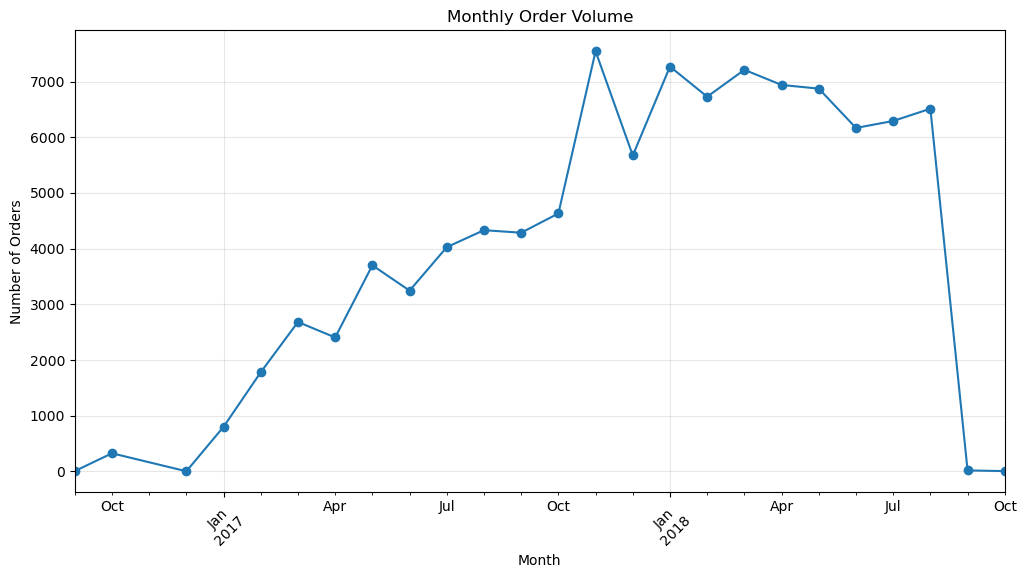

In [29]:
plt.figure(figsize=(12, 6))

Monthly_orders.plot(kind="line", marker="o")

plt.title("Monthly Order Volume")
plt.xlabel("Month")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)
plt.grid(alpha=0.3)

plt.show()

In [30]:
Monthly_orders.idxmax(), Monthly_orders.max()

(Period('2017-11', 'M'), 7544)

## Initial Insight

November 2017 had the highest order volume, with 7,544 orders.

This increase may be related to seasonal events such as Black Friday, but further analysis is needed to confirm this hypothesis.

In [31]:
Monthly_orders.loc["2017-10":"2017-12"]

year_month
2017-10    4631
2017-11    7544
2017-12    5673
Freq: M, Name: count, dtype: int64

In [32]:
Monthly_orders.pct_change().loc["2017-10":"2017-12"]

year_month
2017-10    0.080747
2017-11    0.629022
2017-12   -0.248012
Freq: M, Name: count, dtype: float64

### Monthly Growth Insight

November 2017 showed a significant increase in order volume, growing approximately 62.9% compared to October.

In December, order volume decreased by approximately 24.8%, indicating that the November peak may have been driven by a seasonal event, such as Black Friday.

In [33]:
order_items = pd.read_csv("../data/raw/olist_order_items_dataset.csv")
payments = pd.read_csv("../data/raw/olist_order_payments_dataset.csv")

In [34]:
order_items.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [35]:
payments.head()

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45


In [36]:
order_items.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 non-null  object 
 1   order_item_id        112650 non-null  int64  
 2   product_id           112650 non-null  object 
 3   seller_id            112650 non-null  object 
 4   shipping_limit_date  112650 non-null  object 
 5   price                112650 non-null  float64
 6   freight_value        112650 non-null  float64
dtypes: float64(2), int64(1), object(4)
memory usage: 6.0+ MB


In [37]:
payments.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103886 entries, 0 to 103885
Data columns (total 5 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   order_id              103886 non-null  object 
 1   payment_sequential    103886 non-null  int64  
 2   payment_type          103886 non-null  object 
 3   payment_installments  103886 non-null  int64  
 4   payment_value         103886 non-null  float64
dtypes: float64(1), int64(2), object(2)
memory usage: 4.0+ MB


In [38]:
order_items.shape

(112650, 7)

In [39]:
payments.shape

(103886, 5)

In [40]:
order_items['order_id'].nunique()

98666

In [41]:
payments['order_id'].nunique()

99440

In [42]:
order_items.duplicated().sum()

np.int64(0)

In [43]:
payments.duplicated().sum()

np.int64(0)

In [44]:
payment_by_order = (
    payments
    .groupby('order_id', as_index=False)['payment_value']
    .sum()
)

In [45]:
payment_by_order.head()

,order_id,payment_value
0,00010242fe8c5a6d1ba2dd792cb16214,72.19
1,00018f77f2f0320c557190d7a144bdd3,259.83
2,000229ec398224ef6ca0657da4fc703e,216.87
3,00024acbcdf0a6daa1e931b038114c75,25.78
4,00042b26cf59d7ce69dfabb4e55b4fd9,218.04


In [46]:
payment_by_order.shape

(99440, 2)

In [47]:
order_full = orders.merge(
    payment_by_order,
    on='order_id',
    how='left'
)

In [48]:
order_full.shape

(99441, 12)

In [49]:
orders.shape

(99441, 11)

In [50]:
order_full.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,purchase_year,purchase_month,year_month,payment_value
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,2017,10,2017-10,38.71
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,2018,7,2018-07,141.46
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,2018,8,2018-08,179.12
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,2017,11,2017-11,72.20
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,2018,2,2018-02,28.62


In [51]:
order_full.columns

Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date',
       'purchase_year', 'purchase_month', 'year_month', 'payment_value'],
      dtype='object')

In [52]:
order_full['payment_value'].isnull().sum()

np.int64(1)

In [53]:
order_full['payment_value'].sum()

np.float64(16008872.120000001)

In [54]:
order_full['payment_value'].mean()

np.float64(160.9902666934835)

### Revenue Overview

The dataset contains approximately R$16.0 million in total payments.

The average order value is approximately R$160.99 per order.

In [55]:
monthly_payments = (
    order_full
    .groupby('year_month', as_index=False)['payment_value']
    .sum()
)

In [56]:
monthly_payments.head()

,year_month,payment_value
0,2016-09,252.24
1,2016-10,59090.48
2,2016-12,19.62
3,2017-01,138488.04
4,2017-02,291908.01


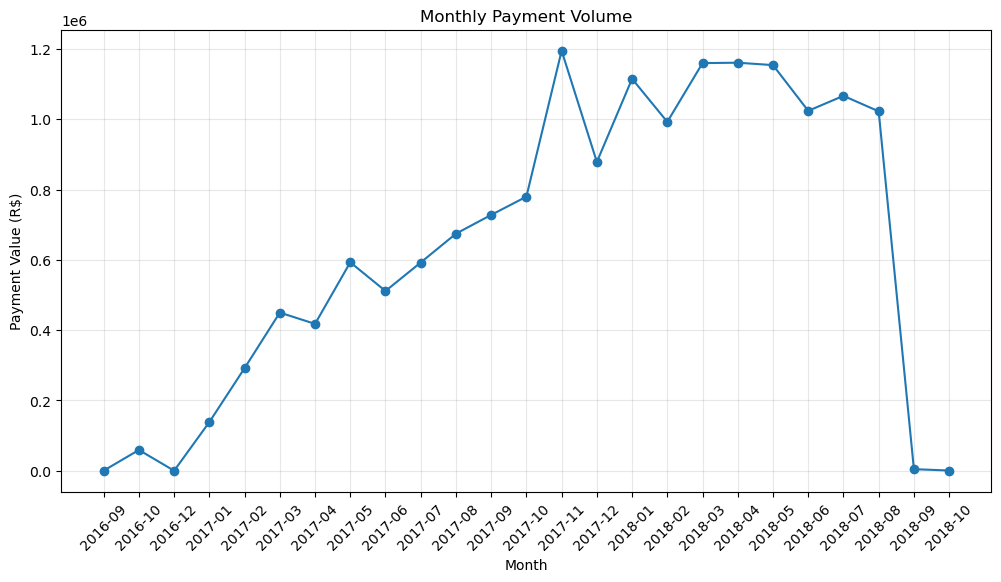

In [57]:
plt.figure(figsize=(12, 6))

plt.plot(
    monthly_payments["year_month"].astype(str),
    monthly_payments["payment_value"],
    marker="o"
)

plt.title("Monthly Payment Volume")
plt.xlabel("Month")
plt.ylabel("Payment Value (R$)")
plt.xticks(rotation=45)
plt.grid(alpha=0.3)

plt.show()

In [58]:
order_full["year_month"].value_counts().sort_index()

year_month
2016-09       4
2016-10     324
2016-12       1
2017-01     800
2017-02    1780
2017-03    2682
2017-04    2404
2017-05    3700
2017-06    3245
2017-07    4026
2017-08    4331
2017-09    4285
2017-10    4631
2017-11    7544
2017-12    5673
2018-01    7269
2018-02    6728
2018-03    7211
2018-04    6939
2018-05    6873
2018-06    6167
2018-07    6292
2018-08    6512
2018-09      16
2018-10       4
Freq: M, Name: count, dtype: int64

In [59]:
all_months = pd.period_range(
    start=order_full['year_month'].min(),
    end=order_full['year_month'].max(),
    freq="M"
)

In [60]:
monthly_payments_complete = (
    monthly_payments
    .set_index('year_month')
    .reindex(all_months, fill_value=0)
    .rename_axis('year_month')
    .reset_index()
)

In [61]:
monthly_payments_complete.head()

,year_month,payment_value
0,2016-09,252.24
1,2016-10,59090.48
2,2016-11,0.00
3,2016-12,19.62
4,2017-01,138488.04


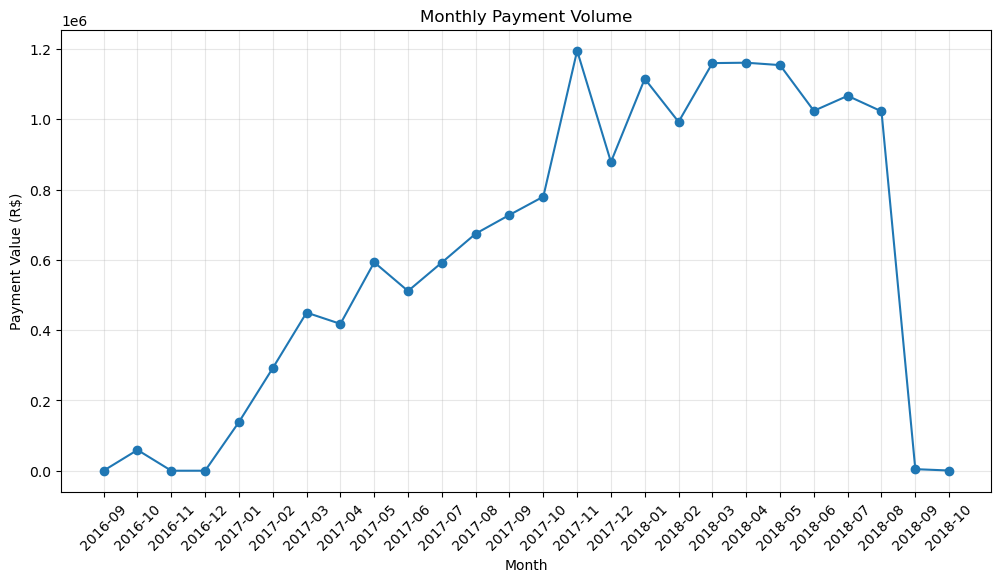

In [62]:
plt.figure(figsize=(12, 6))

plt.plot(
    monthly_payments_complete["year_month"].astype(str),
    monthly_payments_complete["payment_value"],
    marker="o"
)

plt.title("Monthly Payment Volume")
plt.xlabel("Month")
plt.ylabel("Payment Value (R$)")
plt.xticks(rotation=45)
plt.grid(alpha=0.3)

plt.show()

### Monthly Payment Insight

Monthly payment volume increased significantly throughout 2017 and reached its highest level in November 2017.

The payment trend closely follows the order volume trend, suggesting that the growth in total payments was mainly driven by higher order volume.

The sharp decline at the end of the series should be interpreted carefully, as the dataset may have incomplete coverage for the final months.

In [63]:
monthly_avg_ticket = (
    order_full
    .groupby('year_month', as_index=False)['payment_value']
    .mean()
)

In [64]:
monthly_avg_ticket.head()

,year_month,payment_value
0,2016-09,84.080000
1,2016-10,182.378025
2,2016-12,19.620000
3,2017-01,173.110050
4,2017-02,163.993264


In [65]:
monthly_avg_ticket_complete = (
    monthly_avg_ticket
    .set_index("year_month")
    .reindex(all_months)
    .rename_axis("year_month")
    .reset_index()
)

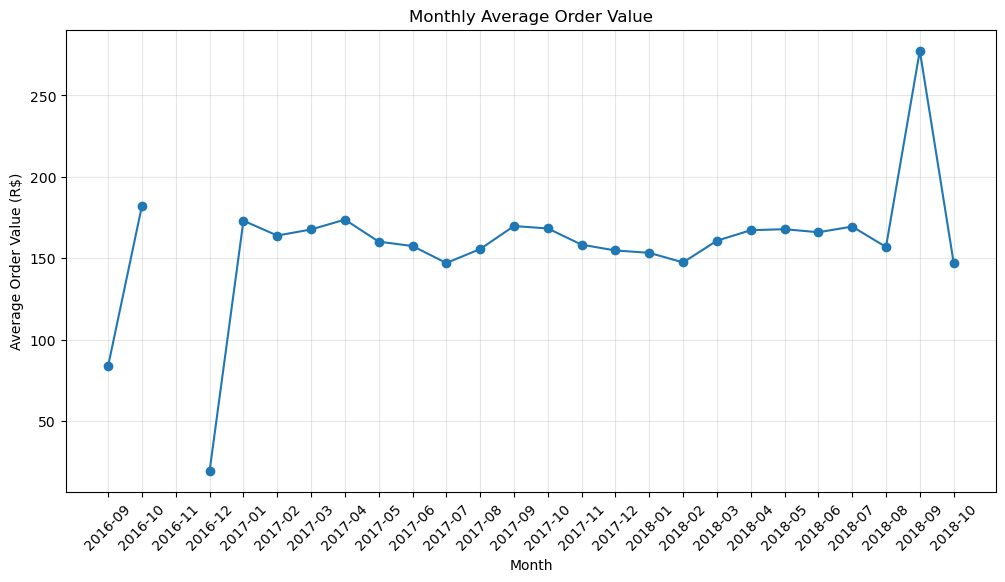

In [66]:
plt.figure(figsize=(12, 6))

plt.plot(
    monthly_avg_ticket_complete["year_month"].astype(str),
    monthly_avg_ticket_complete["payment_value"],
    marker="o"
)

plt.title("Monthly Average Order Value")
plt.xlabel("Month")
plt.ylabel("Average Order Value (R$)")
plt.xticks(rotation=45)
plt.grid(alpha=0.3)

plt.show()

### Average Order Value Insight

The average order value remained relatively stable throughout most of the analyzed period.

In November 2017, the sharp increase in total payment volume was not accompanied by a similar increase in average order value.

This suggests that the November peak was primarily driven by a higher number of orders rather than significantly higher spending per order.

In [67]:
order_full[
    order_full["year_month"] == "2018-09"
][["order_id", "payment_value"]]

,order_id,payment_value
1801,ed3efbd3a87bea76c2812c66a0b32219,191.46
5149,ea844c92cf978ea23321fa7fe5871761,414.04
9976,87ae60ef8b08ae0e5f903cacb53a6904,258.67
16366,bd35b677fd239386e9861d11ae98ab56,84.58
20778,4d59cc2a2e7bb6c0a851725f5888a9b5,69.46
24410,0d3adebce4bebc1f80a7f36e9833f497,94.63
31170,21a00b08cbeb5716bbb66105e3dbd850,51.17
33979,5aac76cf7b07dd06fa4d50bf461d2f40,221.54
37003,869997fbe01f39d184956b5c6bccfdbe,94.63
39919,4637ca194b6387e2d538dc89b124b0ee,0.00


In [68]:
order_full[
    order_full["year_month"] == "2018-09"
]["payment_value"].describe()

count      16.000000
mean      277.471250
std       539.530762
min         0.000000
25%        84.580000
50%       122.080000
75%       203.547500
max      2266.610000
Name: payment_value, dtype: float64

### Outlier and Sample Size Insight

September 2018 presented an unusually high average order value of approximately R$277.

However, the month contains only 16 orders, and the maximum payment value reached R$2,266.61.

The large difference between the mean (R$277.47) and median (R$122.08) suggests that the average was strongly influenced by high-value outliers.

Therefore, September 2018 should not be directly compared with months containing a much larger number of orders.

## Next Steps

- Analyze payment distribution and outliers
- Explore product categories
- Analyze customer location
- Summarize key business insights
- Prepare README and GitHub repository

In [69]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [70]:
orders
order_items
payments
order_full

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,purchase_year,purchase_month,year_month,payment_value
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,2017,10,2017-10,38.71
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,2018,7,2018-07,141.46
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,2018,8,2018-08,179.12
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,2017,11,2017-11,72.20
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,2018,2,2018-02,28.62
...,...,...,...,...,...,...,...,...,...,...,...,...
99436,9c5dedf39a927c1b2549525ed64a053c,39bd1228ee8140590ac3aca26f2dfe00,delivered,2017-03-09 09:54:05,2017-03-09 09:54:05,2017-03-10 11:18:03,2017-03-17 15:08:01,2017-03-28,2017,3,2017-03,85.08
99437,63943bddc261676b46f01ca7ac2f7bd8,1fca14ff2861355f6e5f14306ff977a7,delivered,2018-02-06 12:58:58,2018-02-06 13:10:37,2018-02-07 23:22:42,2018-02-28 17:37:56,2018-03-02,2018,2,2018-02,195.00
99438,83c1379a015df1e13d02aae0204711ab,1aa71eb042121263aafbe80c1b562c9c,delivered,2017-08-27 14:46:43,2017-08-27 15:04:16,2017-08-28 20:52:26,2017-09-21 11:24:17,2017-09-27,2017,8,2017-08,271.01
99439,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,2018-01-08 21:28:27,2018-01-08 21:36:21,2018-01-12 15:35:03,2018-01-25 23:32:54,2018-02-15,2018,1,2018-01,441.16


In [71]:
%whos

Variable                      Type           Data/Info
------------------------------------------------------
Monthly_orders                Series         Shape: (25,)
all_months                    PeriodIndex    PeriodIndex(['2016-09', '<...>       dtype='period[M]')
col                           str            order_estimated_delivery_date
date_cols                     list           n=5
monthly_avg_ticket            DataFrame      Shape: (25, 2)
monthly_avg_ticket_complete   DataFrame      Shape: (26, 2)
monthly_payments              DataFrame      Shape: (25, 2)
monthly_payments_complete     DataFrame      Shape: (26, 2)
np                            module         <module 'numpy' from 'D:\<...>ges\\numpy\\__init__.py'>
order_full                    DataFrame      Shape: (99441, 12)
order_items                   DataFrame      Shape: (112650, 7)
orders                        DataFrame      Shape: (99441, 11)
payment_by_order              DataFrame      Shape: (99440, 2)
payments   

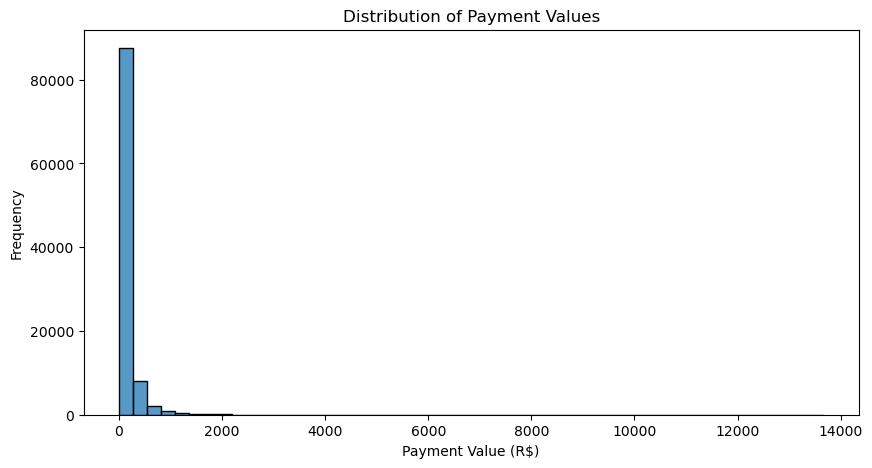

In [72]:
plt.figure(figsize=(10, 5))

sns.histplot(
    order_full["payment_value"].dropna(),
    bins=50
)

plt.title("Distribution of Payment Values")
plt.xlabel("Payment Value (R$)")
plt.ylabel("Frequency")

plt.show()

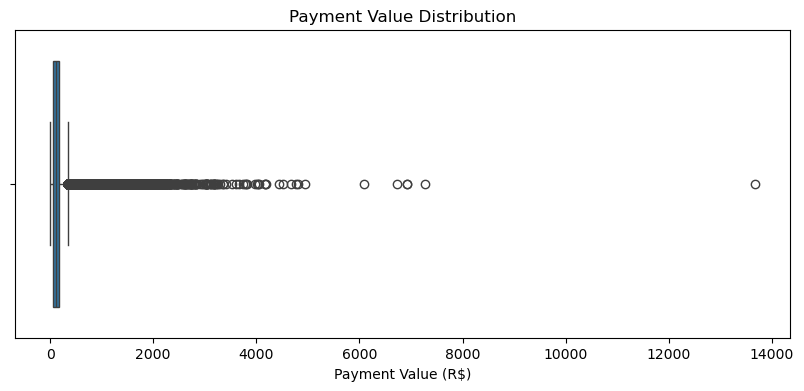

In [73]:
plt.figure(figsize=(10, 4))

sns.boxplot(
    x=order_full["payment_value"].dropna()
)

plt.title("Payment Value Distribution")
plt.xlabel("Payment Value (R$)")

plt.show()

### Payment Distribution Insight

Payment values are highly right-skewed, with most orders concentrated at lower values and a small number of very high-value transactions.

The boxplot confirms the presence of several outliers, which can strongly affect the mean and should be considered when interpreting average order value.

In [74]:
products = pd.read_csv("../data/raw/olist_products_dataset.csv")

In [75]:
products.head()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0


In [76]:
products.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32951 entries, 0 to 32950
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   product_id                  32951 non-null  object 
 1   product_category_name       32341 non-null  object 
 2   product_name_lenght         32341 non-null  float64
 3   product_description_lenght  32341 non-null  float64
 4   product_photos_qty          32341 non-null  float64
 5   product_weight_g            32949 non-null  float64
 6   product_length_cm           32949 non-null  float64
 7   product_height_cm           32949 non-null  float64
 8   product_width_cm            32949 non-null  float64
dtypes: float64(7), object(2)
memory usage: 2.3+ MB


In [78]:
items_products = order_items.merge(
    products,
    on='product_id',
    how='left'
)

In [79]:
items_products.shape

(112650, 15)

In [80]:
items_products.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,cool_stuff,58.0,598.0,4.0,650.0,28.0,9.0,14.0
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,pet_shop,56.0,239.0,2.0,30000.0,50.0,30.0,40.0
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,moveis_decoracao,59.0,695.0,2.0,3050.0,33.0,13.0,33.0
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,perfumaria,42.0,480.0,1.0,200.0,16.0,10.0,15.0
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,ferramentas_jardim,59.0,409.0,1.0,3750.0,35.0,40.0,30.0


In [81]:
order_items.shape

(112650, 7)

In [83]:
items_products[
    ['product_id', 'product_category_name', 'price', 'freight_value']
    ].head()

,product_id,product_category_name,price,freight_value
0,4244733e06e7ecb4970a6e2683c13e61,cool_stuff,58.90,13.29
1,e5f2d52b802189ee658865ca93d83a8f,pet_shop,239.90,19.93
2,c777355d18b72b67abbeef9df44fd0fd,moveis_decoracao,199.00,17.87
3,7634da152a4610f1595efa32f14722fc,perfumaria,12.99,12.79
4,ac6c3623068f30de03045865e4e10089,ferramentas_jardim,199.90,18.14


In [84]:
category_translation = pd.read_csv(
    "../data/raw/product_category_name_translation.csv"
)

In [85]:
category_translation.head()

,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto
3,cama_mesa_banho,bed_bath_table
4,moveis_decoracao,furniture_decor


In [89]:
items_products = items_products.merge(
    category_translation,
    on='product_category_name',
    how='left'
)

In [90]:
items_products[
    ['product_category_name', 'product_category_name_english']
    ].head()

,product_category_name,product_category_name_english
0,cool_stuff,cool_stuff
1,pet_shop,pet_shop
2,moveis_decoracao,furniture_decor
3,perfumaria,perfumery
4,ferramentas_jardim,garden_tools


In [91]:
top_categories = (
    items_products['product_category_name_english']
    .value_counts()
    .head(10)
)

In [92]:
top_categories

product_category_name_english
bed_bath_table           11115
health_beauty             9670
sports_leisure            8641
furniture_decor           8334
computers_accessories     7827
housewares                6964
watches_gifts             5991
telephony                 4545
garden_tools              4347
auto                      4235
Name: count, dtype: int64

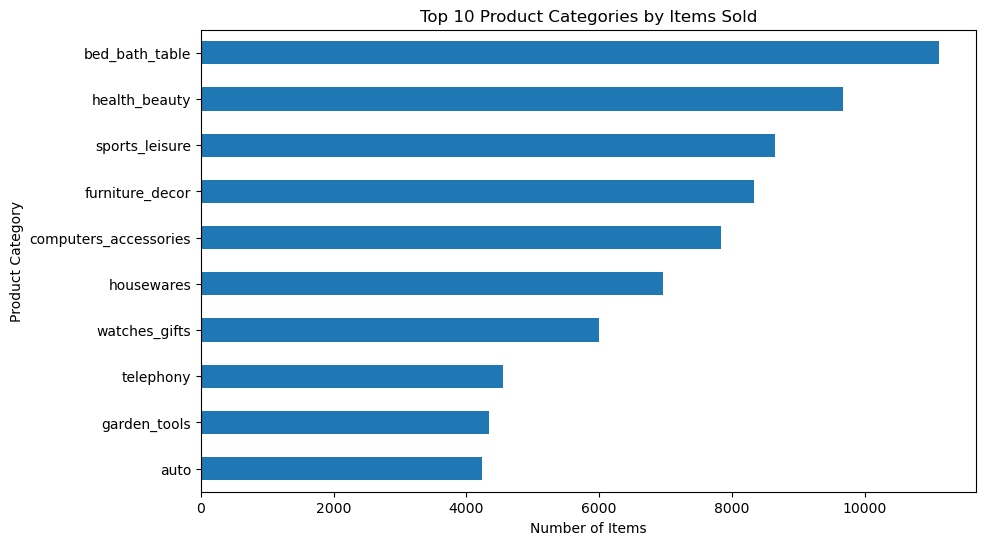

In [93]:
plt.figure(figsize=(10, 6))

top_categories.sort_values().plot(kind="barh")

plt.title("Top 10 Product Categories by Items Sold")
plt.xlabel("Number of Items")
plt.ylabel("Product Category")

plt.show()

### Product Category Insight

Bed, bath and table was the product category with the highest number of items sold.

Health and beauty, sports and leisure, and furniture decor also showed strong sales volume.

However, sales volume alone does not indicate revenue performance, since categories with fewer items sold may generate higher total sales value.

In [94]:
category_revenue = (
    items_products
    .groupby('product_category_name_english', as_index=False)['price']
    .sum()
)

In [95]:
top_revenue_categories = (
    category_revenue
    .sort_values('price', ascending=False)
    .head()
)

In [96]:
top_revenue_categories

,product_category_name_english,price
43,health_beauty,1258681.34
70,watches_gifts,1205005.68
7,bed_bath_table,1036988.68
65,sports_leisure,988048.97
15,computers_accessories,911954.32


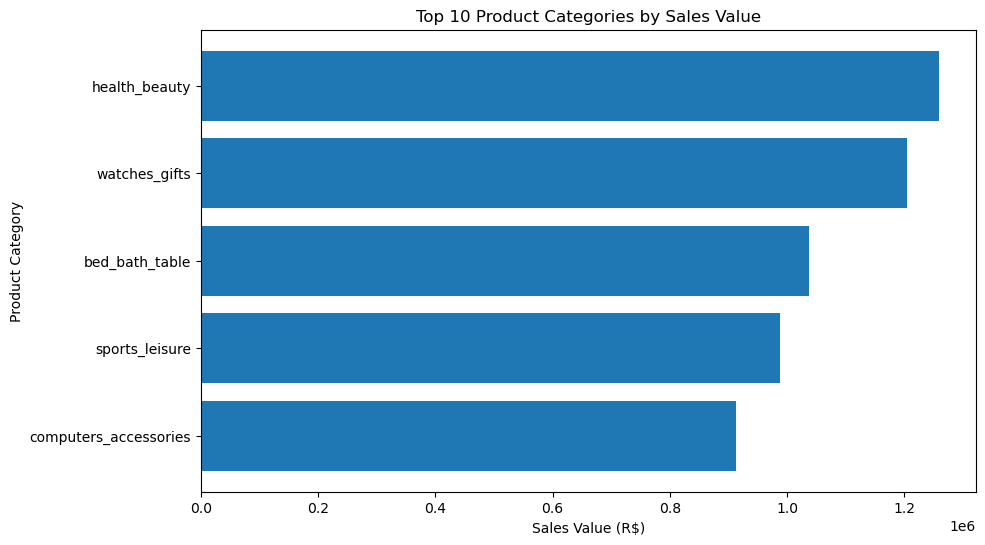

In [97]:
plt.figure(figsize=(10, 6))

plt.barh(
    top_revenue_categories["product_category_name_english"][::-1],
    top_revenue_categories["price"][::-1]
)

plt.title("Top 10 Product Categories by Sales Value")
plt.xlabel("Sales Value (R$)")
plt.ylabel("Product Category")

plt.show()

In [99]:
category_avg_price = (
    items_products
    .groupby('product_category_name_english', as_index=False)['price']
    .mean()
    .sort_values('price', ascending=False)
)

In [100]:
category_avg_price[
    category_avg_price['product_category_name_english'].isin(
        ['health_beauty', 'watches_gifts', 'bed_bath_table']
    )
    ]

,product_category_name_english,price
70,watches_gifts,201.135984
43,health_beauty,130.163531
7,bed_bath_table,93.296327


### Sales Value Insight

The categories with the highest sales volume are not necessarily the categories with the highest sales value.

While bed, bath and table led in number of items sold, health and beauty generated the highest total sales value.

Watches and gifts also ranked highly in sales value despite having a lower sales volume, suggesting a higher average item price.

In [103]:
category_avg_price = (
    items_products
    .groupby('product_category_name_english', as_index=False)['price']
    .mean()
    .sort_values('price',ascending=False)
)

In [104]:
category_avg_price

,product_category_name_english,price
14,computers,1098.340542
64,small_appliances_home_oven_and_coffee,624.285658
45,home_appliances_2,476.124958
0,agro_industry_and_commerce,342.124858
56,musical_instruments,281.616000
...,...,...
37,food_drink,54.602446
11,cds_dvds_musicals,52.142857
23,diapers_and_hygiene,40.194615
35,flowers,33.637576


In [105]:
category_avg_price[
    category_avg_price["product_category_name_english"].isin(
        ["health_beauty", "watches_gifts", "bed_bath_table"]
    )
]

,product_category_name_english,price
70,watches_gifts,201.135984
43,health_beauty,130.163531
7,bed_bath_table,93.296327


In [106]:
customers = pd.read_csv("../data/raw/olist_customers_dataset.csv")

In [107]:
customers.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [108]:
customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB


In [109]:
orders_customers = order_full.merge(
    customers,
    on='customer_id',
    how='left'
)

In [110]:
orders_customers.shape

(99441, 16)

In [112]:
top_states = (
    orders_customers['customer_state']
    .value_counts()
    .head(10)
)

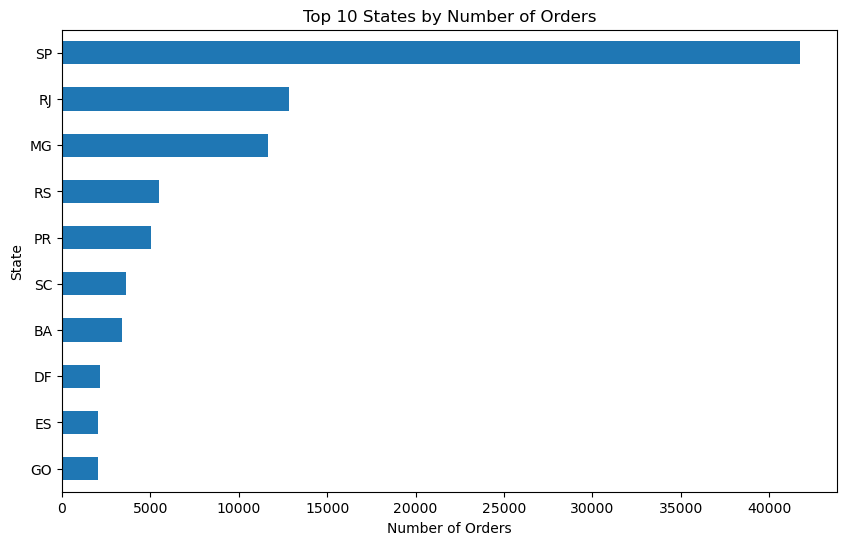

In [113]:
plt.figure(figsize=(10, 6))

top_states.sort_values().plot(kind="barh")

plt.title("Top 10 States by Number of Orders")
plt.xlabel("Number of Orders")
plt.ylabel("State")

plt.show()

In [116]:
state_payment = (
    orders_customers
    .groupby('customer_state', as_index=False)['payment_value']
    .sum()
    .sort_values('payment_value', ascending=False)
    .head(10)
)

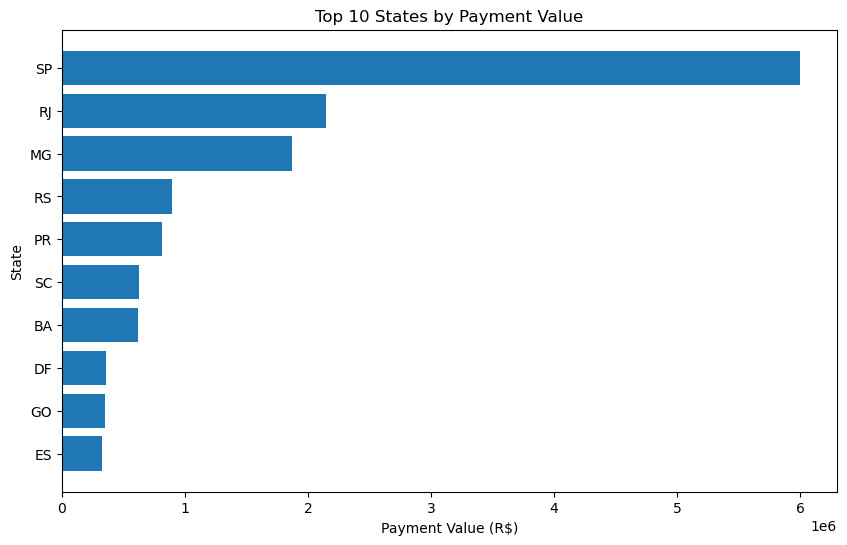

In [117]:
plt.figure(figsize=(10, 6))

plt.barh(
    state_payment["customer_state"][::-1],
    state_payment["payment_value"][::-1]
)

plt.title("Top 10 States by Payment Value")
plt.xlabel("Payment Value (R$)")
plt.ylabel("State")

plt.show()

## Key Business Insights

- Order volume increased significantly throughout 2017, with November 2017 reaching the highest number of orders.
- The November 2017 peak was mainly driven by higher order volume rather than a significant increase in average order value.
- Payment values are highly right-skewed, with high-value outliers influencing the mean.
- Bed, bath and table led in number of items sold, while health and beauty generated the highest total sales value.
- São Paulo was the leading state in both order volume and total payment value.

## Conclusion

The analysis shows that business growth was strongly associated with increased order volume, especially during seasonal peaks.

It also highlights the importance of evaluating both sales volume and monetary value, since the categories with the highest number of items sold were not necessarily the ones generating the highest sales value.

Geographically, São Paulo represented the strongest market in the dataset.